                     Normal day  High volatility day  Crash day
XGBoost                  0.0003               0.0078     0.1349
Random Forest            0.0001               0.0002     0.0000
Extra Trees              0.0605               0.1996     0.1052
Logistic Regression      0.0014               0.0065     0.3571
Meta Learner             0.0001               0.0002     0.0000


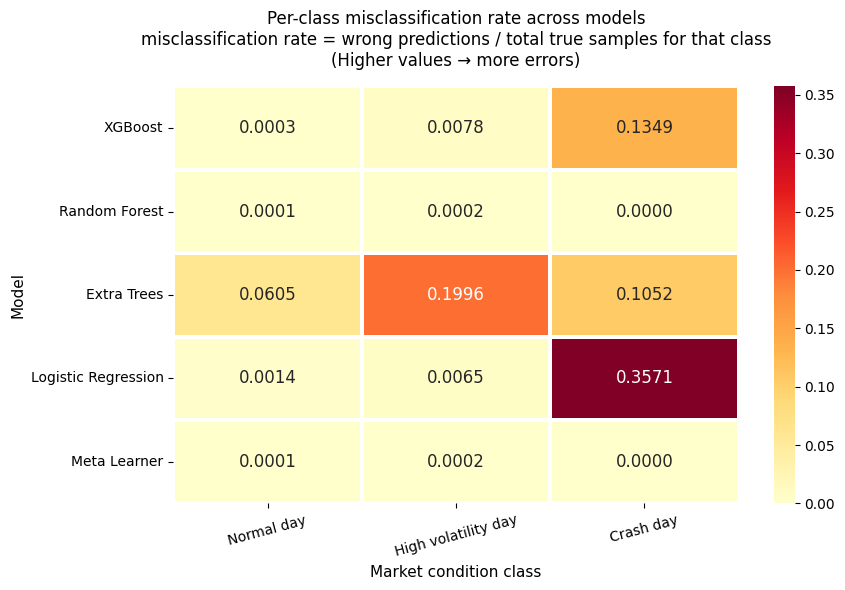

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cms = {
    'XGBoost': np.array([
        [161947, 20,    30 ],
        [363,    51566, 40 ],
        [46,     22,    436]
    ]),
    'Random Forest': np.array([
        [161984, 0,     13 ],
        [9,      51958, 2  ],
        [0,      0,     504]
    ]),
    'Extra Trees': np.array([
        [152202, 5671,  4124],
        [6931,   41597, 3441],
        [44,     9,     451 ]
    ]),
    'Logistic Regression': np.array([
        [161775, 185,   37 ],
        [306,    51629, 34 ],
        [36,     144,   324]
    ]),
    'Meta Learner': np.array([
        [165315, 0,  15],
        [7,      52728, 4],
        [0,      0,  750]
    ]),
}

classes = ['Normal day', 'High volatility day', 'Crash day']
models  = list(cms.keys())

# COMPUTE PER-CLASS MISCLASSIFICATION RATE
# misclassification rate = (FP + FN) / total per class
# = 1 - (TP / row_sum)  i.e. 1 - recall per class

error_data = {}

for model, cm in cms.items():
    row = {}
    for i, cls in enumerate(classes):
        row_sum = cm[i, :].sum()
        TP      = cm[i, i]
        row[cls] = round(1 - (TP / row_sum), 4)
    error_data[model] = row

error_df = pd.DataFrame(error_data).T
error_df.columns = classes

print(error_df)


fig, ax = plt.subplots(figsize=(9, 6))

sns.heatmap(
    error_df,
    annot=True,
    fmt=".4f",
    cmap="YlOrRd",
    linewidths=1.5,
    linecolor='white',
    annot_kws={"size": 12},
    ax=ax
)

ax.set_title(
    "Per-class misclassification rate across models\n"
    "misclassification rate = wrong predictions / total true samples for that class\n"
    "(Higher values → more errors)",
    fontsize=12, pad=15
)
ax.set_xlabel("Market condition class", fontsize=11)
ax.set_ylabel("Model", fontsize=11)
ax.tick_params(axis='x', rotation=15)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

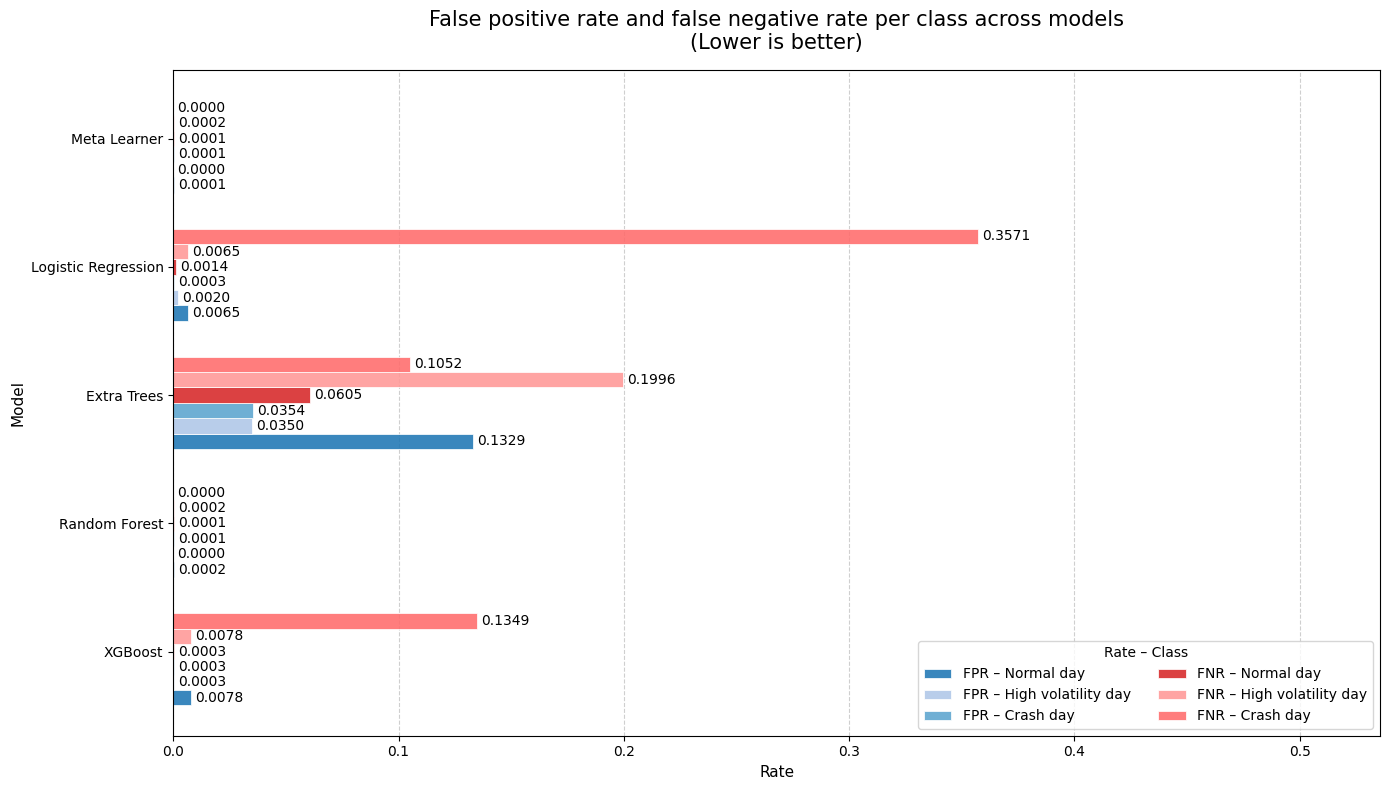

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cms = {
    'XGBoost': np.array([
        [161947, 20,    30 ],
        [363,    51566, 40 ],
        [46,     22,    436]
    ]),
    'Random Forest': np.array([
        [161984, 0,     13 ],
        [9,      51958, 2  ],
        [0,      0,     504]
    ]),
    'Extra Trees': np.array([
        [152202, 5671,  4124],
        [6931,   41597, 3441],
        [44,     9,     451 ]
    ]),
    'Logistic Regression': np.array([
        [161775, 185,   37 ],
        [306,    51629, 34 ],
        [36,     144,   324]
    ]),
    'Meta Learner': np.array([
        [165315, 0,  15],
        [7,      52728, 4],
        [0,      0,  750]
    ]),
}

models  = list(cms.keys())
classes = ['Normal day', 'High volatility day', 'Crash day']

def compute_fpr_fnr(cm, class_idx):
    TP = cm[class_idx, class_idx]
    FN = cm[class_idx, :].sum() - TP
    FP = cm[:, class_idx].sum() - TP
    TN = cm.sum() - TP - FN - FP
    FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
    FNR = FN / (FN + TP) if (FN + TP) > 0 else 0
    return round(FPR, 4), round(FNR, 4)

rate_labels = (
    [f'FPR – {cls}' for cls in classes] +
    [f'FNR – {cls}' for cls in classes]
)

rate_matrix = {label: [] for label in rate_labels}

for model in models:
    cm = cms[model]
    for i, cls in enumerate(classes):
        fpr, fnr = compute_fpr_fnr(cm, i)
        rate_matrix[f'FPR – {cls}'].append(fpr)
        rate_matrix[f'FNR – {cls}'].append(fnr)


n_groups = len(rate_labels)
y        = np.arange(len(models))
height   = 0.12
colors   = ['#1f77b4', '#aec7e8', '#5ba4cf',
            '#d62728', '#ff9896', '#ff6b6b']

fig, ax = plt.subplots(figsize=(14, 8))

offset = -(n_groups // 2) * height

for i, (label, color) in enumerate(zip(rate_labels, colors)):
    bars = ax.barh(
        y + offset + i * height,
        rate_matrix[label],
        height,
        label=label,
        color=color,
        alpha=0.88,
        edgecolor='white',
        linewidth=0.6
    )
    ax.bar_label(bars, fmt='%.4f', fontsize=10,
                 padding=3)

ax.set_title(
    "False positive rate and false negative rate per class across models\n"
    "(Lower is better)",
    fontsize=15, pad=15
)
ax.set_ylabel("Model", fontsize=11)
ax.set_xlabel("Rate", fontsize=11)
ax.set_yticks(y)
ax.set_yticklabels(models, fontsize=10)
ax.set_xlim(0, max(
    max(v) for v in rate_matrix.values()
) * 1.5)
ax.legend(fontsize=10, title="Rate – Class", title_fontsize=10,
          loc='lower right', ncol=2)
ax.xaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()